# Goal

Make some plots for DRR paper

# Load in Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, QTable, join
import astropy.units as u
import pandas as pd
import pickle
from importlib import reload
import wsu_plots
import wsu_db
import drr_plots
import re

# Load in data

In [2]:
wsu_all = QTable.read('data/wsu_datarates_mit_per_mous_initial_goal_20250423.ecsv')

In [3]:
wsu_all.columns

<TableColumns names=('mous','proposal_id','schedblock_name','array','science_keyword','scientific_category','scientific_category_proposal','nant_typical','nant_array','nant_all','band','ntarget','s_fov','s_resolution','mosaic','imsize','pb','cell','blc_npol','blc_nspw','blc_specwidth','blc_freq','blc_velres','blc_nchan_agg','blc_nchan_max','blc_bandwidth_max','blc_bandwidth_agg','wsu_freq','wsu_npol','wsu_bandwidth_early','wsu_bandwidth_later_2x','wsu_bandwidth_later_4x','wsu_bandwidth_spw','wsu_nspw_early','wsu_nspw_later_2x','wsu_nspw_later_4x','wsu_specwidth_finest','wsu_chanavg_finest','wsu_velres_finest','wsu_specwidth_stepped','wsu_chanavg_stepped','wsu_velres_stepped','wsu_specwidth_stepped2','wsu_chanavg_stepped2','wsu_velres_stepped2','wsu_tint','wsu_nchan_spw_finest','wsu_nchan_spw_stepped','wsu_nchan_spw_stepped2','wsu_nchan_agg_finest_early','wsu_nchan_agg_finest_later_2x','wsu_nchan_agg_finest_later_4x','wsu_nchan_agg_stepped_early','wsu_nchan_agg_stepped_later_2x','wsu_nc

In [32]:
wsu_tp = QTable.read('data/tp_database_cycle7_cycle8_permous_20240315.ecsv')

In [5]:
wsu_tp.columns

<TableColumns names=('mous','proposal_id','gous','schedblock_name','array','science_keyword','scientific_category','band','ntarget','s_fov','s_resolution','mosaic','imsize','pb','cell','blc_npol','blc_nspw','blc_specwidth','blc_freq','blc_velres','blc_nchan_agg','blc_nchan_max','blc_bandwidth_max','blc_bandwidth_agg','wsu_freq','wsu_npol','wsu_bandwidth_early','wsu_bandwidth_goal','wsu_bandwidth_later_4x','wsu_bandwidth_spw','wsu_nspw_early','wsu_nspw_goal','wsu_nspw_later_4x','wsu_specwidth_stepped2','wsu_chanavg_stepped2','wsu_velres_stepped2','wsu_nchan_spw_stepped2','wsu_nchan_agg_stepped2_early','wsu_nchan_agg_stepped2_goal','wsu_nchan_agg_stepped2_later_4x','wsu_frac_bw_early','wsu_frac_bw_goal','wsu_frac_bw_later_4x','wsu_frac_bw_spw','CYCLE','ESTIMATED_EXECUTION_TIME_PRJ','ESTIMATED_EXECUTION_TIME_PRJ_UNIT','ACASPEC_INTEGRATION_DURATION','EXECOUNT','N_TDUMP','t_obs','wsu_datarate_tp_goal','wsu_datarate_tp_later_4x','wsu_datavol_tp_goal','wsu_datavol_tp_later_4x')>

In [6]:
#andres = Table.read('andres_comparison/m5_dq_and_sizes.csv')
andres = Table.read('andres_comparison/m5_extrapolations_all_arrays_l80_v3.csv')

In [7]:
andres.columns

<TableColumns names=('sb_uid','mous_status_uid','sb_name','project_code','array','n_sources','n_eb','m5_tint','m5_channel_number','n_ant_avg','m5_channel_width_kms','m5_data_rate_gb_per_s','n_avg','total_time_s','m5_size_gb','size_gb','dq_gb','m5_dq_gb','dq_if_ima_gb','m5_dq_if_ima_gb','m5_channels_per_spw','dq_if_non_ima_gb','m5_dq_if_non_ima_gb','l80_avg_m')>

In [8]:
len(andres)

5822

In [9]:
np.unique(andres['array'])

12 [m]
7 [m]
Total Power


In [10]:
# doing some renaming to make my life easier
idx = andres['array'] == 'Total Power'
andres['array'][idx] = 'TP'

In [11]:
idx = andres['array'] == '12 [m]'
andres['array'][idx] = '12m'

In [12]:
idx = andres['array'] == '7 [m]'
andres['array'][idx] = '7m'

In [13]:
np.unique(andres['array'])

12m
7m
TP


In [14]:
andres.add_column(andres['m5_dq_gb']/andres['m5_size_gb'],name='m5_dq_ratio')

In [15]:
andres.add_column(andres['m5_dq_if_ima_gb']/andres['m5_size_gb'],name='m5_dq_if_ima_ratio')

In [16]:
andres.add_column(andres['m5_dq_if_non_ima_gb']/andres['m5_size_gb'],name='m5_dq_if_non_ima_ratio')

In [17]:
andres.columns

<TableColumns names=('sb_uid','mous_status_uid','sb_name','project_code','array','n_sources','n_eb','m5_tint','m5_channel_number','n_ant_avg','m5_channel_width_kms','m5_data_rate_gb_per_s','n_avg','total_time_s','m5_size_gb','size_gb','dq_gb','m5_dq_gb','dq_if_ima_gb','m5_dq_if_ima_gb','m5_channels_per_spw','dq_if_non_ima_gb','m5_dq_if_non_ima_gb','l80_avg_m','m5_dq_ratio','m5_dq_if_ima_ratio','m5_dq_if_non_ima_ratio')>

In [18]:
idx = andres['array'] != 'TP'
andres_if = andres[idx]

In [19]:
len(andres_if)

5211

In [20]:
idx = andres['array'] == 'TP'
andres_tp = andres[idx]

In [21]:
len(andres_tp)

611

## Overview of data

In [22]:
idx = andres['array'] == '12m'
len(andres[idx])

3180

In [23]:
idx = andres['array'] == '7m'
len(andres[idx])

2031

In [24]:
idx = andres['array'] == 'TP'
len(andres[idx])

611

In [25]:
len(andres)

5822

# Make Data Overview Plots

In [26]:
wsu_all['wsu_datarate_goal_stepped2_typical'].unit

Unit("Gbyte / s")

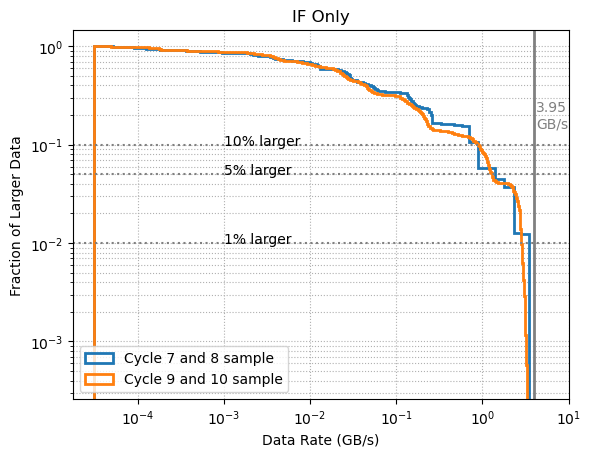

In [27]:
reload(drr_plots)
drr_plots.plot_db1_vs_db2_sample_datarate(wsu_all, andres_if,
                                          filename='andres_plots/cycle7-8_vs_cycle9-10_datarate.png')

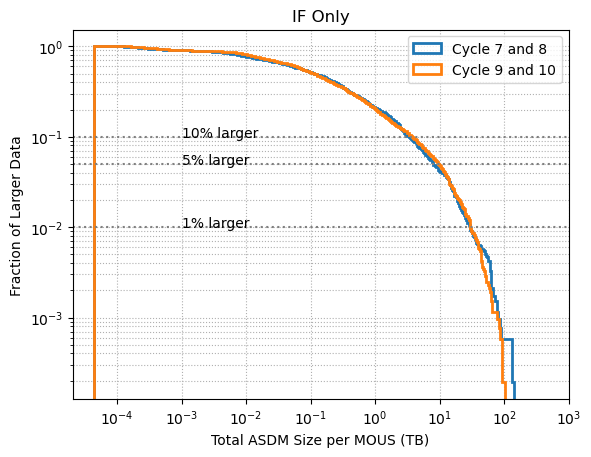

In [28]:
reload(drr_plots)
drr_plots.plot_db1_vs_db2_sample_datavol(wsu_all,andres_if,
                                         filename='andres_plots/cycle7-8_vs_cycle9-10_datavol.png')

In [29]:
wsu_tp.columns

<TableColumns names=('mous','proposal_id','gous','schedblock_name','array','science_keyword','scientific_category','band','ntarget','s_fov','s_resolution','mosaic','imsize','pb','cell','blc_npol','blc_nspw','blc_specwidth','blc_freq','blc_velres','blc_nchan_agg','blc_nchan_max','blc_bandwidth_max','blc_bandwidth_agg','wsu_freq','wsu_npol','wsu_bandwidth_early','wsu_bandwidth_goal','wsu_bandwidth_later_4x','wsu_bandwidth_spw','wsu_nspw_early','wsu_nspw_goal','wsu_nspw_later_4x','wsu_specwidth_stepped2','wsu_chanavg_stepped2','wsu_velres_stepped2','wsu_nchan_spw_stepped2','wsu_nchan_agg_stepped2_early','wsu_nchan_agg_stepped2_goal','wsu_nchan_agg_stepped2_later_4x','wsu_frac_bw_early','wsu_frac_bw_goal','wsu_frac_bw_later_4x','wsu_frac_bw_spw','CYCLE','ESTIMATED_EXECUTION_TIME_PRJ','ESTIMATED_EXECUTION_TIME_PRJ_UNIT','ACASPEC_INTEGRATION_DURATION','EXECOUNT','N_TDUMP','t_obs','wsu_datarate_tp_goal','wsu_datarate_tp_later_4x','wsu_datavol_tp_goal','wsu_datavol_tp_later_4x')>

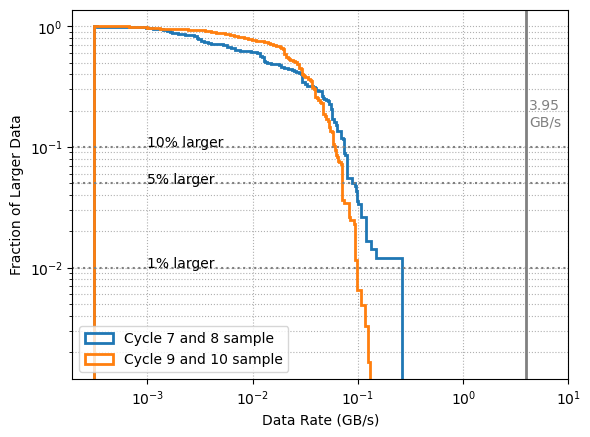

In [33]:
reload(drr_plots)
drr_plots.plot_db1_vs_db2_sample_datarate(wsu_tp, andres_tp,
                                         quant1='wsu_datarate_tp_goal',
                                         quant2='m5_data_rate_gb_per_s',if_only=False)

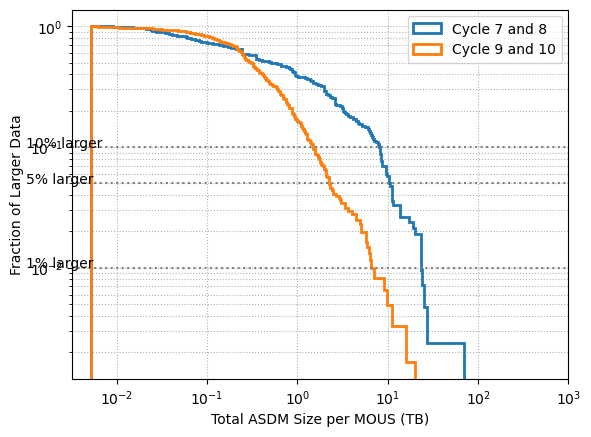

In [34]:
reload(drr_plots)
drr_plots.plot_db1_vs_db2_sample_datavol(wsu_tp, andres_tp,
                                         quant1='wsu_datavol_tp_goal',
                                         quant2='m5_size_gb',if_only=False)

In [35]:
wsu_all.columns

<TableColumns names=('mous','proposal_id','schedblock_name','array','science_keyword','scientific_category','scientific_category_proposal','nant_typical','nant_array','nant_all','band','ntarget','s_fov','s_resolution','mosaic','imsize','pb','cell','blc_npol','blc_nspw','blc_specwidth','blc_freq','blc_velres','blc_nchan_agg','blc_nchan_max','blc_bandwidth_max','blc_bandwidth_agg','wsu_freq','wsu_npol','wsu_bandwidth_early','wsu_bandwidth_later_2x','wsu_bandwidth_later_4x','wsu_bandwidth_spw','wsu_nspw_early','wsu_nspw_later_2x','wsu_nspw_later_4x','wsu_specwidth_finest','wsu_chanavg_finest','wsu_velres_finest','wsu_specwidth_stepped','wsu_chanavg_stepped','wsu_velres_stepped','wsu_specwidth_stepped2','wsu_chanavg_stepped2','wsu_velres_stepped2','wsu_tint','wsu_nchan_spw_finest','wsu_nchan_spw_stepped','wsu_nchan_spw_stepped2','wsu_nchan_agg_finest_early','wsu_nchan_agg_finest_later_2x','wsu_nchan_agg_finest_later_4x','wsu_nchan_agg_stepped_early','wsu_nchan_agg_stepped_later_2x','wsu_nc

In [36]:
overlap_table = join(wsu_all,andres,keys_left='mous',keys_right='mous_status_uid')

In [37]:
len(overlap_table)

62

In [38]:
overlap_table.keys()

['mous',
 'proposal_id',
 'schedblock_name',
 'array_1',
 'science_keyword',
 'scientific_category',
 'scientific_category_proposal',
 'nant_typical',
 'nant_array',
 'nant_all',
 'band',
 'ntarget',
 's_fov',
 's_resolution',
 'mosaic',
 'imsize',
 'pb',
 'cell',
 'blc_npol',
 'blc_nspw',
 'blc_specwidth',
 'blc_freq',
 'blc_velres',
 'blc_nchan_agg',
 'blc_nchan_max',
 'blc_bandwidth_max',
 'blc_bandwidth_agg',
 'wsu_freq',
 'wsu_npol',
 'wsu_bandwidth_early',
 'wsu_bandwidth_later_2x',
 'wsu_bandwidth_later_4x',
 'wsu_bandwidth_spw',
 'wsu_nspw_early',
 'wsu_nspw_later_2x',
 'wsu_nspw_later_4x',
 'wsu_specwidth_finest',
 'wsu_chanavg_finest',
 'wsu_velres_finest',
 'wsu_specwidth_stepped',
 'wsu_chanavg_stepped',
 'wsu_velres_stepped',
 'wsu_specwidth_stepped2',
 'wsu_chanavg_stepped2',
 'wsu_velres_stepped2',
 'wsu_tint',
 'wsu_nchan_spw_finest',
 'wsu_nchan_spw_stepped',
 'wsu_nchan_spw_stepped2',
 'wsu_nchan_agg_finest_early',
 'wsu_nchan_agg_finest_later_2x',
 'wsu_nchan_agg_fin

In [39]:
overlap_table_subset = overlap_table['mous','nEB','wsu_datarate_goal_stepped2_typical','wsu_datavol_goal_stepped2_typical_total','bp_time','flux_time','phase_time','pol_time','check_time','target_time_tot','time_tot']
overlap_table_subset.write('andres_comparison/overlap_20250813.ecsv',overwrite=True)

# Make Main Result Plots

In [40]:
andres.columns

<TableColumns names=('sb_uid','mous_status_uid','sb_name','project_code','array','n_sources','n_eb','m5_tint','m5_channel_number','n_ant_avg','m5_channel_width_kms','m5_data_rate_gb_per_s','n_avg','total_time_s','m5_size_gb','size_gb','dq_gb','m5_dq_gb','dq_if_ima_gb','m5_dq_if_ima_gb','m5_channels_per_spw','dq_if_non_ima_gb','m5_dq_if_non_ima_gb','l80_avg_m','m5_dq_ratio','m5_dq_if_ima_ratio','m5_dq_if_non_ima_ratio')>

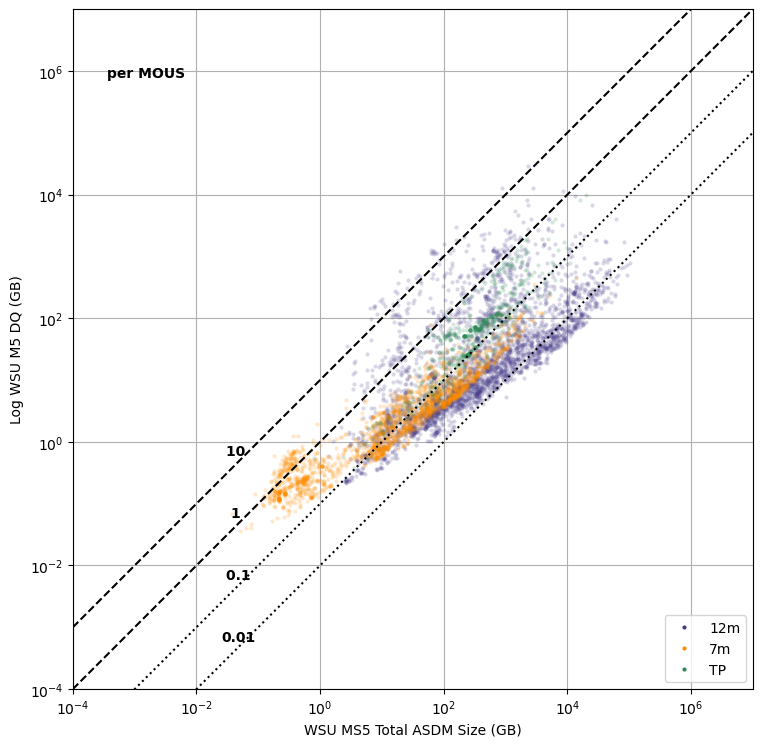

In [41]:
reload(drr_plots)
drr_plots.plot_asdm_vs_dq_points(andres, dq_val='m5_dq_gb', 
                                 xlim=(1e-4,1e7), ylim=(1e-4,1e7),
                                 filename='andres_plots/dq_vs_asdm.png')

In [42]:
n_samp = len(andres)
idx = andres['m5_dq_ratio'] >= 1.0
n_dq_ratio_gt1 = len(andres[idx])
frac = n_dq_ratio_gt1 / n_samp
print(n_samp,n_dq_ratio_gt1, frac*100)

5822 411 7.0594297492270695


In [43]:
n_samp = np.sum(andres['array'] == '12m')
idx = (andres['m5_dq_ratio'] >= 1.0) & (andres['array'] == '12m')
n_dq_ratio_gt1 = len(andres[idx])
frac = n_dq_ratio_gt1 / n_samp
print(n_samp,n_dq_ratio_gt1,frac*100)

3180 270 8.49056603773585


In [44]:
n_samp = np.sum(andres['array'] == '7m')
idx = (andres['m5_dq_ratio'] >= 1.0) & (andres['array'] == '7m')
n_dq_ratio_gt1 = len(andres[idx])
frac = n_dq_ratio_gt1 / n_samp
print(n_samp,n_dq_ratio_gt1, frac*100)

2031 137 6.745445593303791


In [45]:
n_samp = np.sum(andres['array'] == 'TP')
idx = (andres['m5_dq_ratio'] >= 1.0) & (andres['array'] == 'TP')
n_dq_ratio_gt1 = len(andres[idx])
frac = n_dq_ratio_gt1 / n_samp
print(n_samp,n_dq_ratio_gt1, frac*100)

611 4 0.6546644844517185


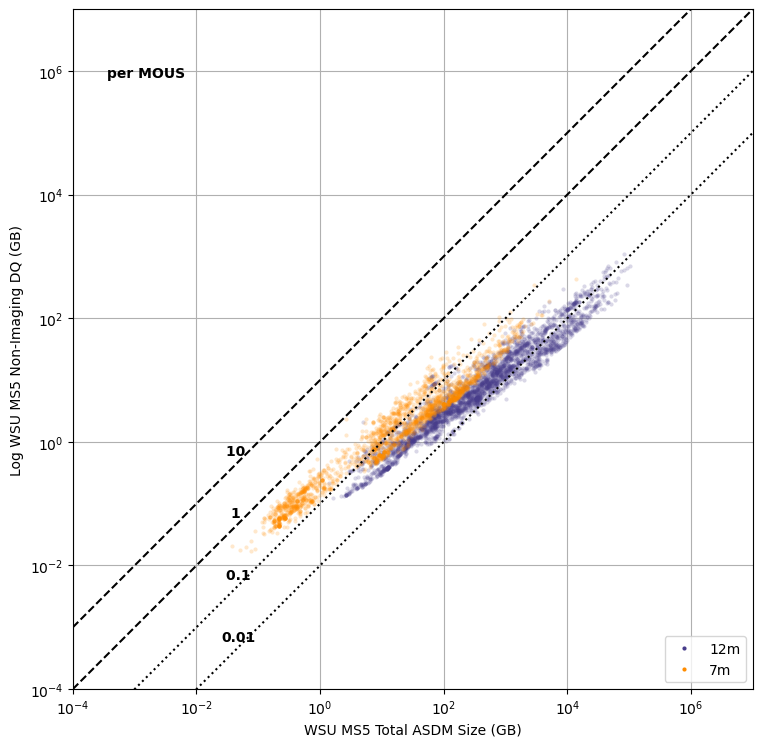

In [46]:
reload(drr_plots)
drr_plots.plot_asdm_vs_dq_points(andres_if, dq_val='m5_dq_if_non_ima_gb',
                                 xlim=(1e-4,1e7), ylim=(1e-4,1e7),
                                 filename='andres_plots/dq_non_ima_vs_asdm.png')

In [47]:
n_if_samp = len(andres_if)
idx = andres_if['m5_dq_if_ima_ratio'] >= 1.0
n_if_dq_ratio_gt1 = len(andres_if[idx])
print(n_if_samp,n_if_dq_ratio_gt1)

5211 347


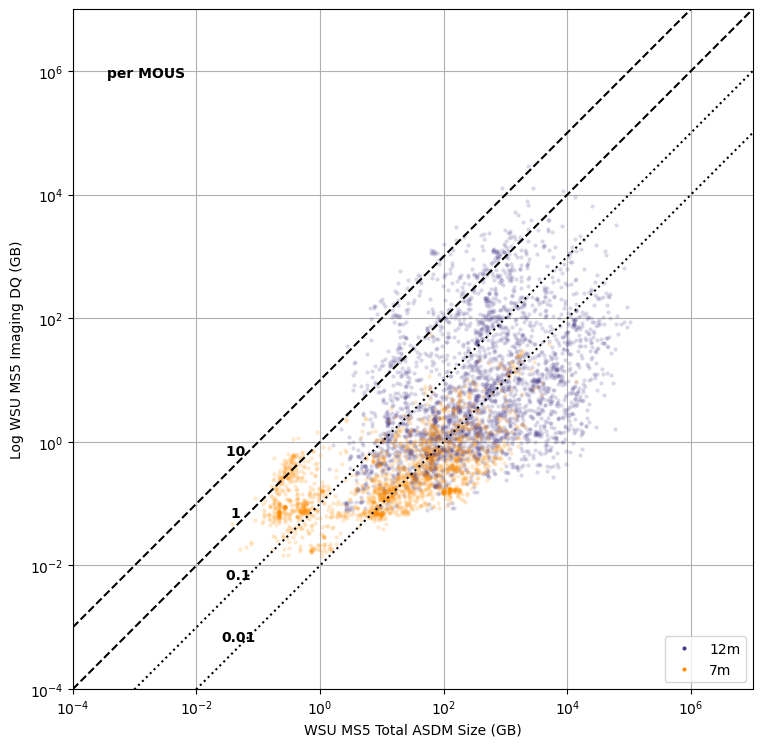

In [49]:
reload(drr_plots)
drr_plots.plot_asdm_vs_dq_points(andres_if, dq_val='m5_dq_if_ima_gb',
                                 xlim=(1e-4,1e7), ylim=(1e-4,1e7),
                                 filename='andres_plots/dq_ima_vs_asdm.png')

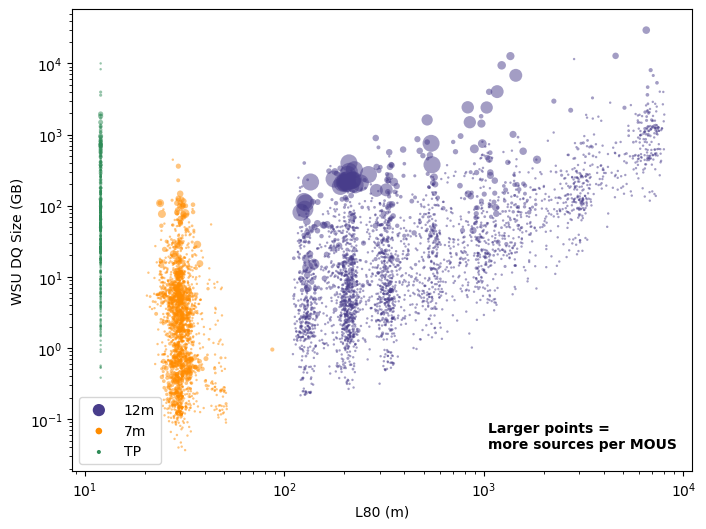

In [50]:
reload(drr_plots)
drr_plots.plot_dq_ratio_vs_l80(andres,dq_val='m5_dq_gb',
                               array_list = ['12m','7m','TP'],
                               filename='andres_plots/dq_vs_l80.png')

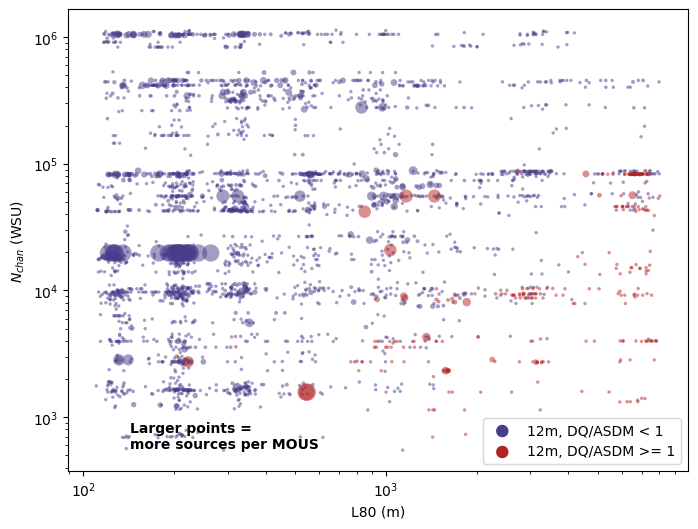

In [51]:
reload(drr_plots)
drr_plots.plot_l80_vs_nchan(andres,dq_val='m5_dq_ratio',array_list=['12m'],
                           filename='andres_plots/dq_ratio_l80_vs_nchan_12m.png')

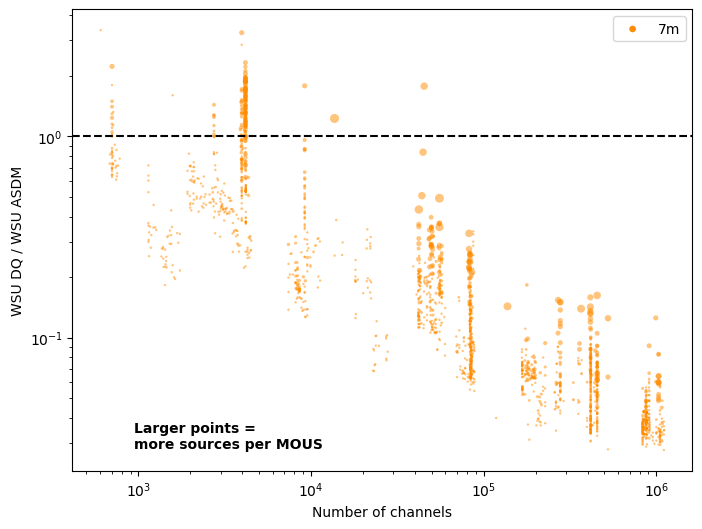

In [52]:
reload(drr_plots)
drr_plots.plot_dq_ratio_vs_nchan(andres,dq_val='m5_dq_ratio', array_list=['7m'], 
                                filename='andres_plots/dq_ratio_vs_nchan_7m.png')

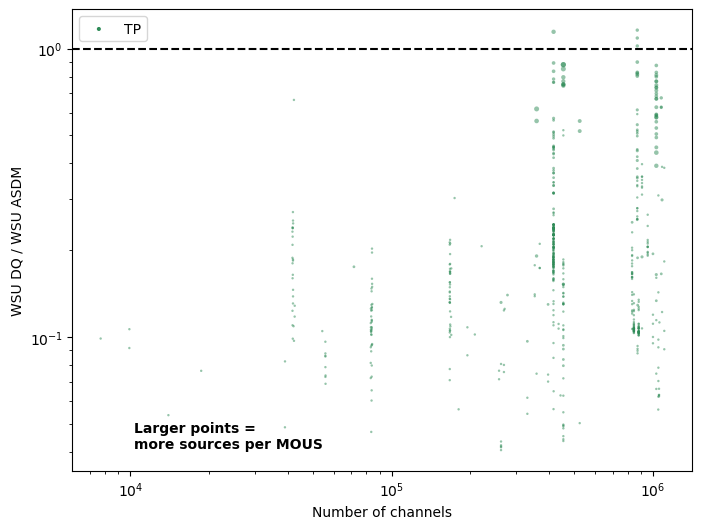

In [53]:
reload(drr_plots)
drr_plots.plot_dq_ratio_vs_nchan(andres,dq_val='m5_dq_ratio',array_list=['TP'],
                                filename='andres_plots/dq_ratio_vs_nchan_TP.png')

In [54]:
np.sum(andres['n_sources'] > 1.0)

1385

In [55]:
len(andres)

5822

In [56]:
1385/5822.0

0.23789075918928204